# KKBox Churn — Final Marketing Action Framework

Combines three already-validated pieces of work into one actionable table:

- **Risk tier** — `06_risk_scoring.ipynb` (High/Medium/Low, from the temporal XGBoost model)
- **Behavioral segments** — `07_churn_drivers_segments.ipynb`, independently revalidated (0
  mismatches) in the follow-up check
- **Historical Realized Revenue (HRR)** — `08_marketing_value_analysis.ipynb`'s value proxy
  (explicitly not CLV; see that notebook for the full definition and limitations)

**This notebook does not retrain anything, does not change any segmentation rule, and does not
invent campaign-response numbers.** Every number below is read from existing `outputs/*.csv`
files produced by notebooks 06-08. The one new piece of logic is an "intervention intensity"
label per priority group — computed by re-applying notebook 08's own (unmodified)
risk-x-value recommendation rule to each segment's actual customer-level composition, not a new
judgment call.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Load the already-computed outputs (no recomputation of scores, tiers, or segments)

In [2]:
OUT_DIR = Path("..") / "outputs"

customer_value = pd.read_csv(OUT_DIR / "customer_value_tiers.csv")  # msno, is_churn, risk_tier, segment, total_revenue, value_tier
segment_summary = pd.read_csv(OUT_DIR / "segment_summary.csv")       # validated rules, characteristics, objectives
value_by_segment = pd.read_csv(OUT_DIR / "value_by_segment.csv")     # median/mean/total HRR per segment

print(f"customer_value_tiers.csv: {len(customer_value):,} customers")
print(segment_summary[["segment", "n_customers", "actual_churn_rate_pct"]].to_string(index=False))


customer_value_tiers.csv: 970,960 customers
                                 segment  n_customers  actual_churn_rate_pct
                 At-Risk, Auto-Renew Off       113820                  41.15
                         At-Risk Veteran         6261                  74.48
                        At-Risk Newcomer         1796                  63.86
                At-Risk, Price-Sensitive         1968                  42.94
            Engaged Low-Risk (Champions)       321006                   4.15
UNMATCHED (Medium/High risk, no segment)         5890                  64.72


## 2. Per-customer intervention recommendation (re-applying notebook 08's rule, unchanged)

This is the exact `recommend()` function from `08_marketing_value_analysis.ipynb` §7, copied
verbatim — not a new rule. Applying it per-customer (rather than to the 9 generic risk x value
cells) lets each *segment* inherit a recommendation grounded in its actual risk/value mix, since
segments like "At-Risk Veteran" span more than one risk tier.

In [3]:
def recommend(risk, value):
    if risk == "High" and value in ("High", "Medium"):
        return "High-touch (phone call, largest offer) -- highest ROI cell"
    if risk == "High" and value == "Low":
        return "Low-cost only (email/automated) -- capped spend given limited value at stake"
    if risk == "Medium" and value == "High":
        return "Moderate-touch (proactive outreach before they become High-risk)"
    if risk == "Medium":
        return "Low-cost automated (email, in-app nudge)"
    if risk == "Low" and value == "High":
        return "No retention spend -- redirect to advocacy/upsell (see Champions segment, notebook 07)"
    return "No action -- monitor only"

INTENSITY_MAP = {
    "High-touch (phone call, largest offer) -- highest ROI cell": "High-touch",
    "Moderate-touch (proactive outreach before they become High-risk)": "Moderate-touch",
    "Low-cost only (email/automated) -- capped spend given limited value at stake": "Low-cost / Automated",
    "Low-cost automated (email, in-app nudge)": "Low-cost / Automated",
    "No retention spend -- redirect to advocacy/upsell (see Champions segment, notebook 07)": "Advocacy / Upsell (non-retention)",
    "No action -- monitor only": "Monitor only",
    "Insufficient data (no transaction record)": "Monitor only (no value data)",
}

def per_customer_recommendation(row):
    if row["value_tier"] == "Unknown (no transaction data)":
        return "Insufficient data (no transaction record)"
    return recommend(row["risk_tier"], row["value_tier"])

customer_value["recommendation"] = customer_value.apply(per_customer_recommendation, axis=1)
customer_value["intervention_intensity"] = customer_value["recommendation"].map(INTENSITY_MAP)
print(customer_value["intervention_intensity"].value_counts())


intervention_intensity
Monitor only                         547802
Advocacy / Upsell (non-retention)    292915
Low-cost / Automated                  94401
Moderate-touch                        20894
High-touch                            12421
Monitor only (no value data)           2527
Name: count, dtype: int64


## 3. Define the priority groups

The 5 validated segments from notebook 07, plus the unmatched Medium/High-risk residual
(quantified separately in the follow-up validation) reported as its own row -- not folded
silently into "Stable / Monitor."


In [4]:
at_risk = customer_value["risk_tier"].isin(["High", "Medium"])
is_unmatched_residual = at_risk & (customer_value["segment"] == "Stable / Monitor")

customer_value["priority_group"] = customer_value["segment"]
customer_value.loc[is_unmatched_residual, "priority_group"] = "Unmatched At-Risk (no segment)"

GROUP_ORDER = [
    "At-Risk, Auto-Renew Off", "At-Risk Veteran", "At-Risk Newcomer",
    "At-Risk, Price-Sensitive", "Unmatched At-Risk (no segment)",
    "Engaged Low-Risk (Champions)", "Stable / Monitor",
]
print(customer_value["priority_group"].value_counts().reindex(GROUP_ORDER))


priority_group
At-Risk, Auto-Renew Off           113820
At-Risk Veteran                     6261
At-Risk Newcomer                    1796
At-Risk, Price-Sensitive            1968
Unmatched At-Risk (no segment)      5890
Engaged Low-Risk (Champions)      321006
Stable / Monitor                  520219
Name: count, dtype: int64

## 4. Build the combined action-plan table

In [5]:
RULE_TEXT = dict(zip(segment_summary["segment"], segment_summary["rule_definition"]))
RULE_TEXT["Unmatched At-Risk (no segment)"] = "risk_tier in {High, Medium} AND none of the 5 segment rules matched (see 07 follow-up validation)"

CHAR_TEXT = dict(zip(segment_summary["segment"], segment_summary["key_distinguishing_characteristics"]))
OBJECTIVE_TEXT = dict(zip(segment_summary["segment"], segment_summary["marketing_objective"]))
OBJECTIVE_TEXT["Unmatched At-Risk (no segment)"] = "Standard tier-based treatment per 06_risk_scoring.ipynb; not one of the 5 named segments."
CHAR_TEXT["Unmatched At-Risk (no segment)"] = "No single defining behavioral trait; flagged at-risk by the model on signals other than auto-renew, tenure extremes, or discounting."

# segment_summary.csv (07's follow-up validation) never carried a row for the residual majority
# itself -- it only covers the 5 named segments plus the unmatched-at-risk row. Add it here,
# consistent with how 07_churn_drivers_segments.ipynb described this bucket in its own markdown.
RULE_TEXT["Stable / Monitor"] = "everyone else (default bucket) minus the unmatched at-risk residual above -- i.e. Low risk tier with no standout behavioral pattern"
CHAR_TEXT["Stable / Monitor"] = "Low risk tier; unremarkable auto-renew, tenure, and discount profile -- the majority baseline, not a distinguishing segment."
OBJECTIVE_TEXT["Stable / Monitor"] = "No special campaign; low churn risk and no standout value signal to act on."

rows = []
for name in GROUP_ORDER:
    seg = customer_value[customer_value["priority_group"] == name]
    n = len(seg)
    pct = n / len(customer_value) * 100
    churn_rate = seg["is_churn"].mean() * 100

    valued = seg[seg["value_tier"] != "Unknown (no transaction data)"]
    total_hrr = valued["total_revenue"].sum()
    median_hrr = valued["total_revenue"].median()

    dominant_rec = seg["recommendation"].mode().iloc[0]
    pct_dominant = (seg["recommendation"] == dominant_rec).mean() * 100
    intensity = INTENSITY_MAP[dominant_rec]

    rationale = (
        f"{n:,} customers ({pct:.2f}% of base) with a {churn_rate:.1f}% actual churn rate and "
        f"{total_hrr:,.0f} NT$ in Historical Realized Revenue among them (median {median_hrr:,.0f} "
        f"NT$/customer). {pct_dominant:.0f}% of this group falls into the '{dominant_rec}' cell of "
        f"the risk x value framework from 08_marketing_value_analysis.ipynb, which sets the "
        f"recommended intensity below."
    )

    rows.append({
        "priority_group": name,
        "rule_definition": RULE_TEXT[name],
        "n_customers": n,
        "pct_of_base": round(pct, 2),
        "churn_rate_pct": round(churn_rate, 2),
        "total_HRR": round(float(total_hrr), 2),
        "median_HRR": round(float(median_hrr), 2) if pd.notna(median_hrr) else None,
        "defining_characteristics": CHAR_TEXT[name],
        "marketing_objective": OBJECTIVE_TEXT[name],
        "intervention_intensity": intensity,
        "dominant_risk_value_recommendation": dominant_rec,
        "pct_matching_dominant_recommendation": round(pct_dominant, 1),
        "rationale": rationale,
    })

action_plan = pd.DataFrame(rows)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 50)
action_plan


,priority_group,rule_definition,n_customers,pct_of_base,churn_rate_pct,total_HRR,median_HRR,defining_characteristics,marketing_objective,intervention_intensity,dominant_risk_value_recommendation,pct_matching_dominant_recommendation,rationale
0,"At-Risk, Auto-Renew Off","risk_tier in {High, Medium} AND latest_is_auto...",113820,11.72,41.15,2.004640e+08,1788.0,auto-renew rate 0% vs 88% overall (much lower)...,Direct auto-renew re-enable nudge + small ince...,Low-cost / Automated,"Low-cost automated (email, in-app nudge)",66.0,"113,820 customers (11.72% of base) with a 41.2..."
1,At-Risk Veteran,"risk_tier in {High, Medium} AND tenure_days_at...",6261,0.64,74.48,1.556340e+07,2980.0,auto-renew rate 100% (at/above overall 88%); m...,"Loyalty/appreciation-toned outreach, not a gen...",Low-cost / Automated,"Low-cost automated (email, in-app nudge)",43.1,"6,261 customers (0.64% of base) with a 74.5% a..."
2,At-Risk Newcomer,"risk_tier in {High, Medium} AND tenure_days_at...",1796,0.18,63.86,2.796910e+05,298.0,auto-renew rate 100% (at/above overall 88%); m...,Onboarding-style engagement content; likely a ...,Monitor only (no value data),Insufficient data (no transaction record),51.4,"1,796 customers (0.18% of base) with a 63.9% a..."
3,"At-Risk, Price-Sensitive","risk_tier in {High, Medium} AND discount_rate ...",1968,0.20,42.94,9.263700e+05,180.0,auto-renew rate 100% (at/above overall 88%); a...,Pricing/plan-fit conversation or targeted disc...,Low-cost / Automated,"Low-cost automated (email, in-app nudge)",88.8,"1,968 customers (0.20% of base) with a 42.9% a..."
4,Unmatched At-Risk (no segment),"risk_tier in {High, Medium} AND none of the 5 ...",5890,0.61,64.72,6.249695e+06,1287.0,No single defining behavioral trait; flagged a...,Standard tier-based treatment per 06_risk_scor...,Low-cost / Automated,"Low-cost automated (email, in-app nudge)",63.3,"5,890 customers (0.61% of base) with a 64.7% a..."
5,Engaged Low-Risk (Champions),risk_tier == Low AND total_transactions >= 20 ...,321006,33.06,4.15,1.133760e+09,3633.0,auto-renew rate 100% (at/above overall 88%); m...,"Advocacy/upsell: referrals, plan upgrades, ear...",Advocacy / Upsell (non-retention),No retention spend -- redirect to advocacy/ups...,89.2,"321,006 customers (33.06% of base) with a 4.1%..."
6,Stable / Monitor,everyone else (default bucket) minus the unmat...,520219,53.58,3.21,7.133907e+08,1341.0,"Low risk tier; unremarkable auto-renew, tenure...",No special campaign; low churn risk and no sta...,Monitor only,No action -- monitor only,98.6,"520,219 customers (53.58% of base) with a 3.2%..."


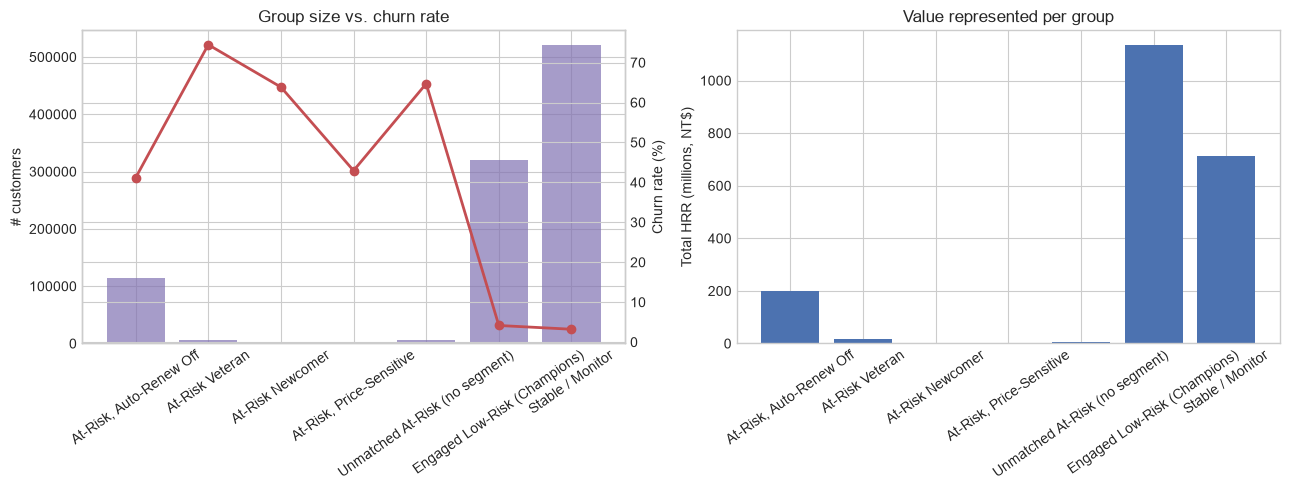

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = GROUP_ORDER
counts = action_plan.set_index("priority_group")["n_customers"].reindex(order)
churn = action_plan.set_index("priority_group")["churn_rate_pct"].reindex(order)
hrr = action_plan.set_index("priority_group")["total_HRR"].reindex(order)

ax2 = axes[0].twinx()
axes[0].bar(order, counts.values, color="#8172B2", alpha=0.7)
ax2.plot(order, churn.values, color="#C44E52", marker="o", linewidth=2)
axes[0].set_ylabel("# customers")
ax2.set_ylabel("Churn rate (%)")
axes[0].set_title("Group size vs. churn rate")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(order, hrr.values / 1e6, color="#4C72B0")
axes[1].set_ylabel("Total HRR (millions, NT$)")
axes[1].set_title("Value represented per group")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


## 5. Save the final framework

In [7]:
action_plan.to_csv(OUT_DIR / "marketing_action_plan.csv", index=False)

with open(OUT_DIR / "marketing_action_plan.json", "w") as f:
    json.dump({
        "sources": [
            "outputs/risk_scoring_predictions.csv (06_risk_scoring.ipynb)",
            "outputs/customer_segments.csv and segment_summary.csv (07_churn_drivers_segments.ipynb, revalidated)",
            "outputs/customer_value_tiers.csv and value_by_segment.csv (08_marketing_value_analysis.ipynb)",
        ],
        "value_proxy_note": "Historical Realized Revenue (HRR) = cumulative actual_amount_paid through 2017-02-28. Not CLV -- see 08_marketing_value_analysis.ipynb for full limitations.",
        "no_retraining_or_new_segmentation": True,
        "priority_groups": action_plan.to_dict(orient="records"),
    }, f, indent=2, default=float)

print("Saved:")
print(" ", OUT_DIR / "marketing_action_plan.csv")
print(" ", OUT_DIR / "marketing_action_plan.json")


Saved:
  ..\outputs\marketing_action_plan.csv
  ..\outputs\marketing_action_plan.json


## 6. The framework -- read directly from the computed table (not asserted here)

In [8]:
for _, r in action_plan.iterrows():
    print(f"{r['priority_group']}")
    print(f"  Intensity: {r['intervention_intensity']}  "
          f"(this label matches {r['pct_matching_dominant_recommendation']:.0f}% of the group's own "
          f"per-customer risk x value cells -- the rest fall into other cells within the same group)")
    print(f"  {r['n_customers']:,} customers ({r['pct_of_base']:.2f}% of base), "
          f"churn rate {r['churn_rate_pct']:.1f}%, total HRR {r['total_HRR']:,.0f} NT$")
    print(f"  Objective: {r['marketing_objective']}")
    print()


At-Risk, Auto-Renew Off
  Intensity: Low-cost / Automated  (this label matches 66% of the group's own per-customer risk x value cells -- the rest fall into other cells within the same group)
  113,820 customers (11.72% of base), churn rate 41.1%, total HRR 200,463,967 NT$
  Objective: Direct auto-renew re-enable nudge + small incentive -- lowest-cost, highest-leverage campaign.

At-Risk Veteran
  Intensity: Low-cost / Automated  (this label matches 43% of the group's own per-customer risk x value cells -- the rest fall into other cells within the same group)
  6,261 customers (0.64% of base), churn rate 74.5%, total HRR 15,563,399 NT$
  Objective: Loyalty/appreciation-toned outreach, not a generic discount.

At-Risk Newcomer
  Intensity: Monitor only (no value data)  (this label matches 51% of the group's own per-customer risk x value cells -- the rest fall into other cells within the same group)
  1,796 customers (0.18% of base), churn rate 63.9%, total HRR 279,691 NT$
  Objective: On

### Reading this honestly

The intensity label for each group is the **mode** of that group's own per-customer risk x value
recommendations from notebook 08's unmodified rule -- not a judgment call written into this
markdown cell. That distinction matters here: **a segment's raw average churn rate does not by
itself determine its recommended intensity.** The `recommend()` rule keys off discrete risk *tier*
(Medium vs. High) and value *tier*, not the segment's overall churn-rate average -- so a segment
that mixes mostly Medium-risk-tier customers with a smaller High-risk-tier subset can resolve to
a lower intensity than its headline churn rate might suggest, if High-value/High-risk customers
are a minority within it. **Check `pct_matching_dominant_recommendation` in the table above before
treating any single intensity label as a strong consensus** -- a value under ~50% means the group
is a genuine mix, and the label is a simplification of that mix, not a uniform description of
every customer in it.

This table is a **direct, mechanical combination of already-published findings** -- every number
in `marketing_action_plan.csv` traces back to a specific cell in an existing `outputs/*.csv` file
from notebooks 06-08, and every recommendation reuses notebook 08's own decision rule rather than
introducing a new one.


## 7. Limitations carried forward (not resolved here)

- **Risk scores are miscalibrated in absolute terms** (`06_risk_scoring.ipynb` §4) — safe for
  ranking/tiering, not for literal probability math.
- **HRR is realized revenue, not CLV** (`08_marketing_value_analysis.ipynb` §2) — past spend is
  assumed to be informative about future value, which is a real assumption, not a proven fact.
- **The temporal validation (`05_temporal_validation.ipynb`) showed real month-to-month
  degradation** in the underlying model — this action plan should be refreshed whenever the model
  is retrained, not treated as permanent.
- **No campaign-response data exists anywhere in this project.** Every "recommended intensity" is
  a reasoned allocation of effort based on churn rate and realized value, not a promise of a
  specific lift, conversion rate, or ROI figure — those would require actually running the
  campaigns and measuring outcomes, which is future work outside this project's data.

**No models were retrained, no segmentation logic was changed, and no existing dataset, model, or
prior output file was modified.** New artifacts: `outputs/marketing_action_plan.csv`,
`outputs/marketing_action_plan.json`.
